# Cross-asset EDA

Examine relationships between instruments using only discovery days 1–500 for pair research: stock-pair correlations, market-wide movement and whether ALGO behaves like an index of the 50 stocks. Days 501–700 are reserved for validation, and days 701–1000 for final testing.

In [54]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.float_format', '{:,.4f}'.format)

repo_root = Path.cwd()
if not (repo_root / 'backtester').exists():
    repo_root = repo_root.parent

DISCOVERY_DAYS = 500
prices_full = pd.read_csv(repo_root / 'backtester' / 'data' / '2026' / 'prices.txt', sep=r'\s+')
prices = prices_full.iloc[:DISCOVERY_DAYS].copy()
assert len(prices_full) >= DISCOVERY_DAYS, 'Not enough observations for the discovery period'
returns = prices.pct_change(fill_method=None)
non_algo_tickers = prices.columns.drop('ALGO')

## Correlation matrix

This matrix shows Pearson correlations of daily returns for the 50 non-ALGO stocks in discovery days 1–500. High correlation is a starting point for pair research, not evidence of a tradable pair or causation.

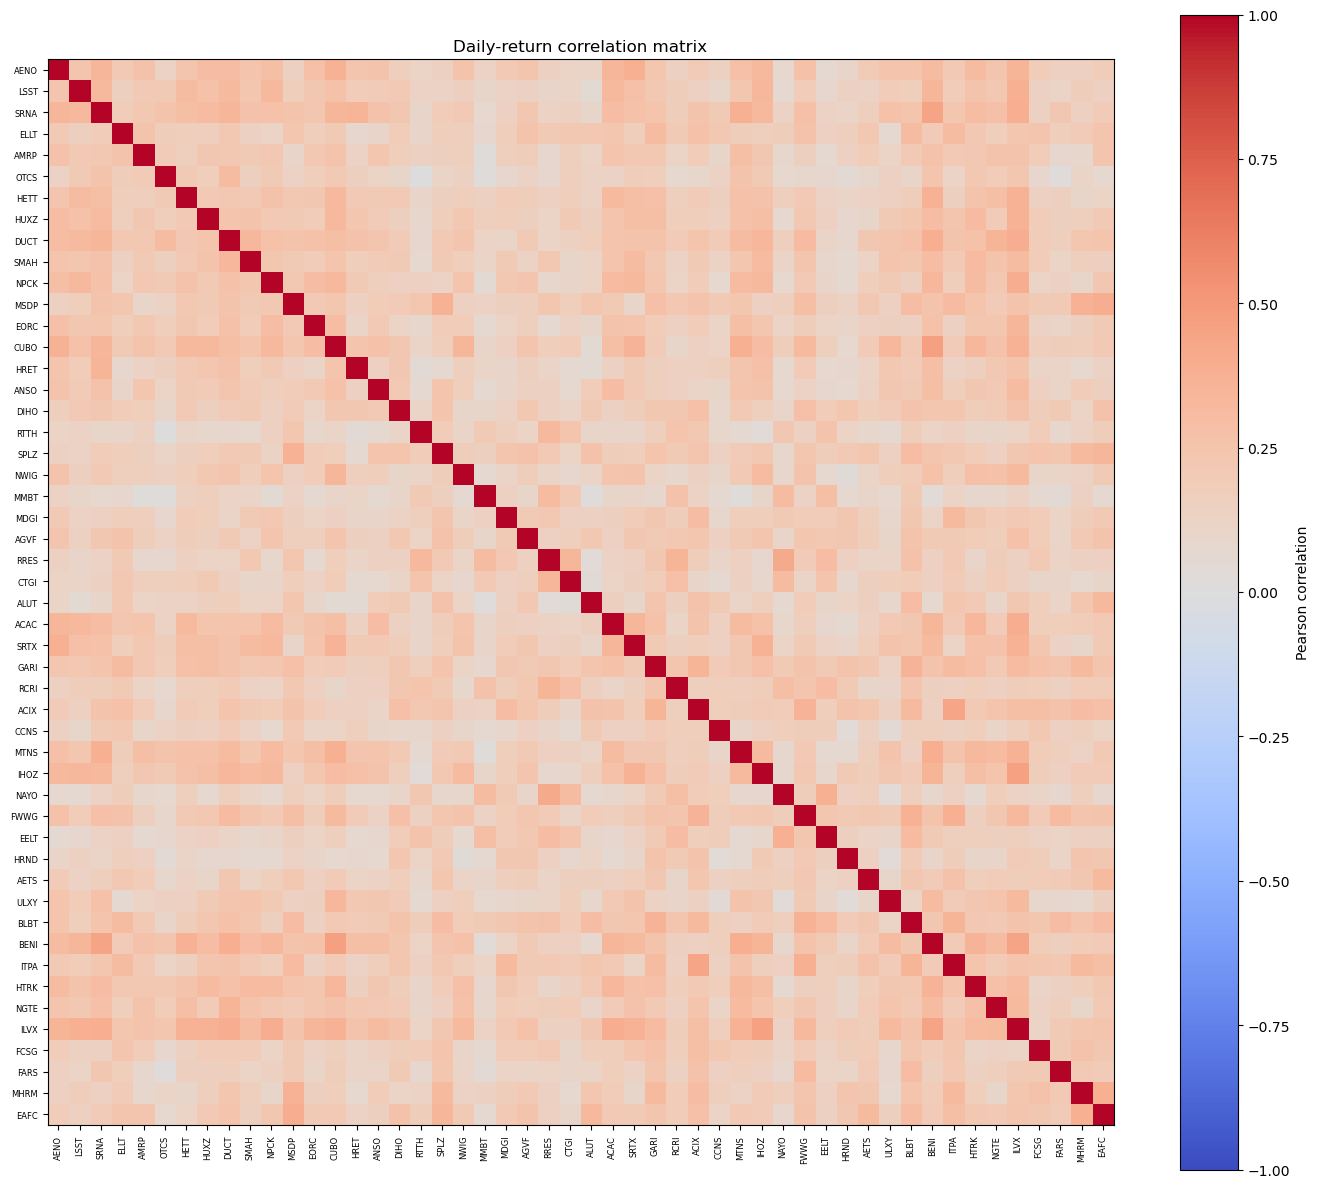

In [55]:
stock_returns = returns[non_algo_tickers]
correlation_matrix = stock_returns.corr()

fig, ax = plt.subplots(figsize=(14, 12))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap='coolwarm')
ax.set(
    title='Daily-return correlation matrix',
    xticks=np.arange(len(correlation_matrix.columns)),
    yticks=np.arange(len(correlation_matrix.index)),
    xticklabels=correlation_matrix.columns,
    yticklabels=correlation_matrix.index,
)
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', labelsize=6)
fig.colorbar(image, ax=ax, label='Pearson correlation')
plt.tight_layout()
plt.show()

In [56]:
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
correlation_pairs = (
    upper_triangle.stack()
    .rename('correlation')
    .rename_axis(['ticker_a', 'ticker_b'])
    .reset_index()
    .assign(abs_correlation=lambda frame: frame['correlation'].abs())
    .sort_values('abs_correlation', ascending=False)
)

display(correlation_pairs.head(15).style.format({
    'correlation': '{:+.3f}',
    'abs_correlation': '{:.3f}',
}))

,ticker_a,ticker_b,correlation,abs_correlation
586,CUBO,BENI,+0.463,0.463
1100,IHOZ,ILVX,+0.455,0.455
1192,BENI,ILVX,+0.445,0.445
135,SRNA,BENI,+0.438,0.438
1046,ACIX,ITPA,+0.437,0.437
884,RRES,NAYO,+0.413,0.413
521,MSDP,EAFC,+0.394,0.394
479,NPCK,ILVX,+0.393,0.393
400,DUCT,ILVX,+0.392,0.392
967,ACAC,ILVX,+0.391,0.391


**Notes / interpretation**

- The strongest return-correlation pair is BENI–ILVX (0.473), followed by FWWG–BLBT (0.447). These are moderate relationships.
- FWWG–ITPA (0.445), IHOZ–ILVX (0.445), and ACIX–ITPA (0.445) are also worth including in the cointegration screen, but correlation alone does not establish mean reversion.

### Pair-screening note

The correlation table above screens non-ALGO stock pairs. A high correlation alone is not enough: investigate the price spread, hedge ratio, stationarity and stability before treating a pair as a candidate strategy.

## Rolling correlations with ALGO

Full-sample correlation can hide changing relationships. Select any stock to see how its 60-day correlation with ALGO changes through time.

In [57]:
rolling_window = 60

def plot_rolling_algo_correlation(ticker):
    rolling_correlation = returns['ALGO'].rolling(rolling_window).corr(returns[ticker])
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rolling_correlation, color='slateblue')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set(
        title=f'{rolling_window}-day rolling correlation: ALGO vs {ticker}',
        xlabel='Day',
        ylabel='Correlation',
        ylim=(-1, 1),
    )
    plt.show()

ticker_selector = widgets.Dropdown(
    options=sorted(non_algo_tickers),
    value=sorted(non_algo_tickers)[0],
    description='Stock:',
)
widgets.interact(plot_rolling_algo_correlation, ticker=ticker_selector);

interactive(children=(Dropdown(description='Stock:', options=('ACAC', 'ACIX', 'AENO', 'AETS', 'AGVF', 'ALUT', …

## Market-wide movement

The equal-weight market proxy is the average daily return of the 50 non-ALGO stocks. Market breadth is the percentage of those stocks with a positive daily return.

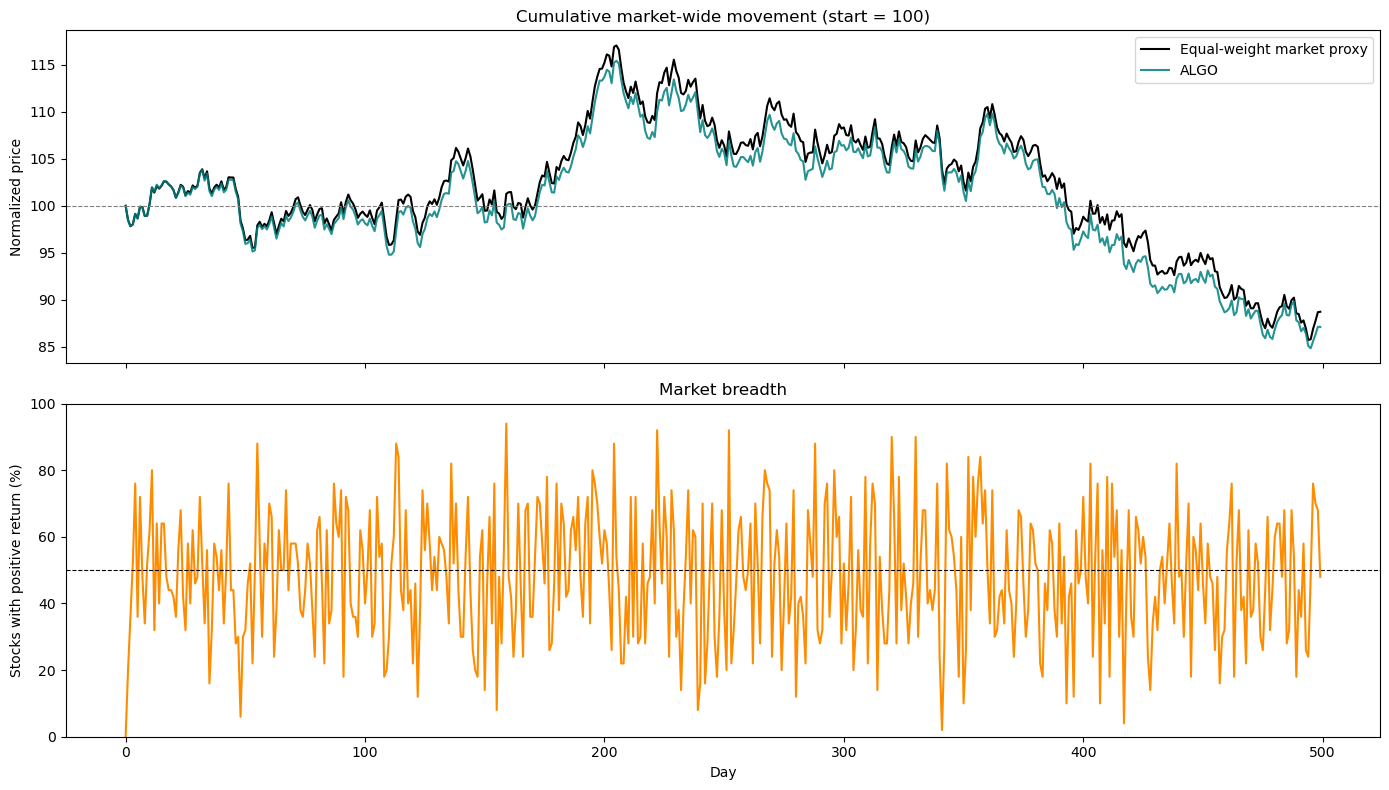

In [58]:
market_return = returns[non_algo_tickers].mean(axis=1)
market_breadth_pct = returns[non_algo_tickers].gt(0).mean(axis=1).mul(100)
market_index = (1 + market_return.fillna(0)).cumprod().mul(100)
algo_index = prices['ALGO'].div(prices['ALGO'].iloc[0]).mul(100)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(market_index, label='Equal-weight market proxy', color='black')
axes[0].plot(algo_index, label='ALGO', color='teal', alpha=0.85)
axes[0].axhline(100, color='grey', linewidth=0.8, linestyle='--')
axes[0].set(title='Cumulative market-wide movement (start = 100)', ylabel='Normalized price')
axes[0].legend()

axes[1].plot(market_breadth_pct, color='darkorange')
axes[1].axhline(50, color='black', linewidth=0.8, linestyle='--')
axes[1].set(title='Market breadth', xlabel='Day', ylabel='Stocks with positive return (%)', ylim=(0, 100))
plt.tight_layout()
plt.show()

**Notes / interpretation**

- The equal-weight market proxy ends near 110.3, while ALGO ends near 109.4, so development days 1–360 have a broadly positive market move.
- Their similar cumulative paths suggest common market-wide movement; the next section quantifies how closely ALGO tracks it.

## Does ALGO behave like an index?

An index-like ALGO series should have high correlation with the equal-weight market proxy, beta near one, and relatively low tracking-error volatility.

,value
daily_return_correlation,0.9931
market_beta,1.0053
mean_daily_alpha_pct,-0.0035
r_squared,0.9863
annualised_tracking_error_pct,1.8421


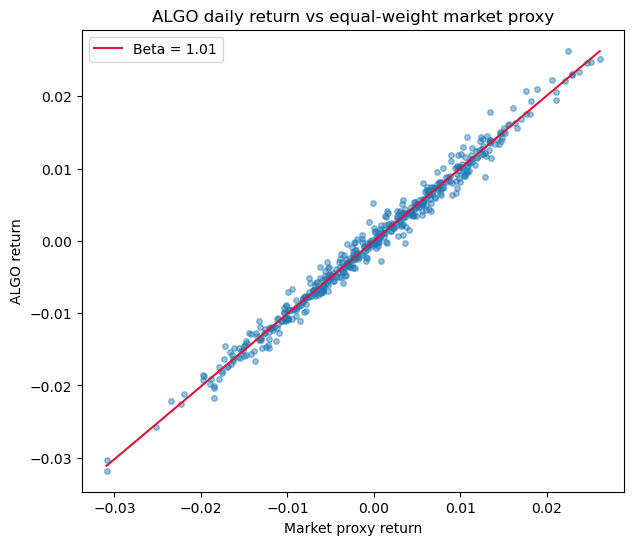

In [59]:
comparison = pd.DataFrame({'ALGO': returns['ALGO'], 'market_proxy': market_return}).dropna()
correlation = comparison['ALGO'].corr(comparison['market_proxy'])
beta = comparison['ALGO'].cov(comparison['market_proxy']) / comparison['market_proxy'].var()
alpha = comparison['ALGO'].mean() - beta * comparison['market_proxy'].mean()
r_squared = correlation ** 2
tracking_error_pct = (comparison['ALGO'] - comparison['market_proxy']).std() * np.sqrt(250) * 100

index_summary = pd.DataFrame({
    'value': [correlation, beta, alpha * 100, r_squared, tracking_error_pct],
}, index=[
    'daily_return_correlation',
    'market_beta',
    'mean_daily_alpha_pct',
    'r_squared',
    'annualised_tracking_error_pct',
])
display(index_summary.style.format('{:.4f}'))

slope, intercept = np.polyfit(comparison['market_proxy'], comparison['ALGO'], 1)
x = np.linspace(comparison['market_proxy'].min(), comparison['market_proxy'].max(), 100)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(comparison['market_proxy'], comparison['ALGO'], alpha=0.45, s=16)
ax.plot(x, intercept + slope * x, color='crimson', label=f'Beta = {beta:.2f}')
ax.set(title='ALGO daily return vs equal-weight market proxy', xlabel='Market proxy return', ylabel='ALGO return')
ax.legend()
plt.show()

**Notes / interpretation**

- ALGO is strongly index-like in discovery data: its daily-return correlation with the equal-weight market proxy is 0.996, beta is 1.006, and R² is 0.992.
- Annualised tracking error is only 1.39%, so ALGO is a useful market benchmark; it should be excluded from stock-pair screens.

## Next steps

- Interpret the strongest and most stable correlations before treating them as pair candidates.
- Test lead-lag relationships and any potential signals on time-respecting holdout windows.